In [3]:
import os
import numpy as np
import seaborn as sns
from numpy.polynomial.legendre import leggauss
from matplotlib import pyplot as plt

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
folder = "./nitscheFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"

directory ./nitscheFEM already created


In [6]:
# Funções analíticas

def exact_u(x):
    return np.cos(np.pi * x)

def exact_f(x):
    return (np.pi ** 2)*np.cos(np.pi*x)

In [7]:
def compute_L2_error(nodes, elements, u_app):
    gauss_pts, weights = leggauss(3)

    error_sq = 0.0

    for e in elements:
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]
        u_loc = np.array([u_app[n1], u_app[n2]])

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])

            x_gp = N[0] * x1 + N[1] * x2
            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

In [8]:
def compute_L2_error_discontinuous(nodes, elements, u_app):
    gauss_pts, weights = leggauss(3)

    error_sq = 0.0

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]
        u_loc = u_app[elem_id, :]

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])

            x_gp = N[0] * x1 + N[1] * x2

            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

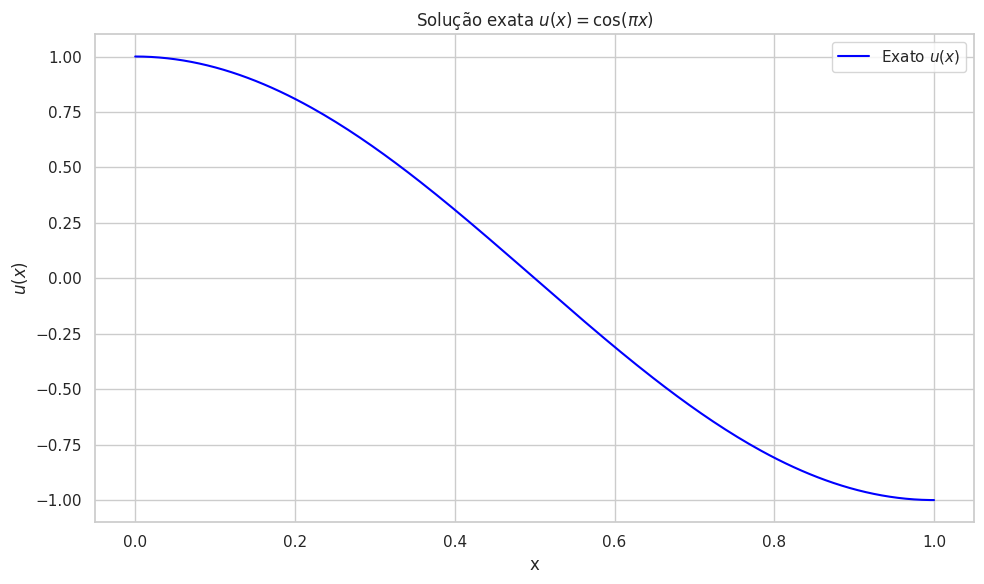

In [9]:
x_exact = np.linspace(0, 1, 200)

plt.figure(figsize=(10, 6))

plt.plot(x_exact, exact_u(x_exact), '-', label=r'Exato $u(x)$', color='blue')

plt.title(r'Solução exata $u(x) = \cos(\pi x)$')
plt.xlabel('x')
plt.ylabel(r'$u(x)$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "exato.pdf")
plt.show()

In [10]:
# Função de criação de malha

def create_mesh(l, n_elem):
    nodes = np.linspace(0, l, n_elem+1)
    elements = np.array([[i, i+1] for i in range(n_elem)])
    return nodes, elements

In [11]:
def local_matrices(x1, x2):
    h = x2 - x1
    J = h / 2.0  # Jacobiano da transformação

    # Pontos e pesos da Quadratura de Gauss
    gauss_pts = [-1/np.sqrt(3), 1/np.sqrt(3)]
    weights = [1.0, 1.0]

    K_loc = np.zeros((2, 2))
    F_loc = np.zeros(2)

    for gp, w in zip(gauss_pts, weights):
        # Aqui defino as funções de forma (N) e derivadas (dN/dx) para a aproximação linear
        N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])
        dN_dxi = np.array([-0.5, 0.5])
        dN_dx = dN_dxi / J

        # Coordenada x real no ponto de integração
        x_gp = N[0]*x1 + N[1]*x2
        f_val = exact_f(x_gp)

        for i in range(2):
            F_loc[i] += f_val * N[i] * w * J
            for j in range(2):
                K_uu = dN_dx[i] * dN_dx[j]
                K_loc[i, j] += K_uu * w * J

    return K_loc, F_loc

In [12]:
# Montagem Global e Resolução com Nitsche
def solve_nitsche(l, n_elem, alpha, beta):
    nodes, elements = create_mesh(l, n_elem)
    n_nodes = len(nodes)
    n_dof = n_nodes

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    # 1. Montagem Padrão (Volume)
    for e in elements:
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]
        K_loc, F_loc = local_matrices(x1, x2)

        dofs = [n1, n2]

        for i in range(2):
            F_global[dofs[i]] += F_loc[i]
            for j in range(2):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    # 2. Imposição Fraca das Condições de Dirichlet (Nitsche)
    h = l / n_elem
    g_0 = exact_u(0.0)
    g_1 = exact_u(l)

    # Contorno em x = 0 (Nó 0)
    K_global[0, 0] += -1.0/h + alpha/h + beta
    K_global[0, 1] += 1.0/h
    K_global[1, 0] += -alpha/h
    
    F_global[0] += (alpha/h + beta) * g_0
    F_global[1] += (-alpha/h) * g_0

    # Contorno em x = L (Nó final)
    N_idx = n_elem
    K_global[N_idx, N_idx] += -1.0/h + alpha/h + beta
    K_global[N_idx, N_idx-1] += 1.0/h
    K_global[N_idx-1, N_idx] += -alpha/h
    
    F_global[N_idx] += (alpha/h + beta) * g_1
    F_global[N_idx-1] += (-alpha/h) * g_1

    # Resolução do sistema linear
    # U_global = np.linalg.solve(K_global, F_global)
    # Tentei fazer aqui uma maneira de evitar que de erro se a matriz for singular... graças a Deus aprendi esse tratamento de exceção
    try:
        u_app = np.linalg.solve(K_global, F_global)
    except np.linalg.LinAlgError:
        print(f"Matriz singular para alpha={alpha}, beta={beta}. Usando mínimos quadrados.")
        u_app = np.linalg.lstsq(K_global, F_global, rcond=None)[0]

    return nodes, elements, u_app, K_global

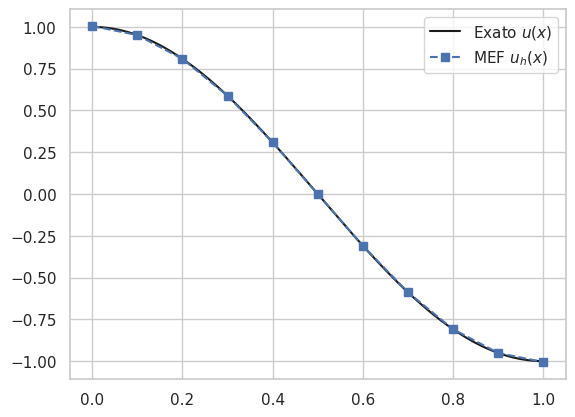

In [13]:
L = 1.0
n_elem = 10

alphas = [-1, 0, 1]
betas = [0, 1, 10, 100]

x_exact = np.linspace(0, L, 200)

nodes, elements, u_approx, K_global = solve_nitsche(L, n_elem=10, alpha=-1, beta=100)

plt.plot(x_exact, exact_u(x_exact), 'k-', label='Exato $u(x)$')
plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.legend()

In [14]:
def experiment_b():
    L = 1.0
    n_elem = 20

    alphas = [-1, 0, 1]
    betas = [0, 1, 10, 100]

    x_exact = np.linspace(0, L, 300)

    plt.figure(figsize=(18, 12))

    print("RESULTADOS LETRA (b) - MÉTODO DE NITSCHE")
    print("-" * 90)
    print(f"{'alpha':<8} | {'beta':<8} | {'Erro L2':<12} | {'cond(K)':<12} | {'u_h(0)':<12} | {'u_h(1)':<12}")
    print("-" * 90)

    count = 1

    for alpha in alphas:
        for beta in betas:
            nodes, elements, u_app, K_global = solve_nitsche(L, n_elem, alpha, beta)

            err_L2 = compute_L2_error(nodes, elements, u_app)
            cond_K = np.linalg.cond(K_global)

            print(
                f"{alpha:<8} | {beta:<8} | {err_L2:<12.3e} | "
                f"{cond_K:<12.3e} | {u_app[0]:<12.6f} | {u_app[-1]:<12.6f}"
            )

            plt.subplot(len(alphas), len(betas), count)

            plt.plot(x_exact, exact_u(x_exact), 'k--', label='Exata')
            plt.plot(nodes, u_app, 'bo-', label='Aproximada')

            plt.title(rf'$\alpha={alpha}$, $\beta={beta}$')
            plt.xlabel('x')
            plt.ylabel('u(x)')
            plt.grid(True)

            if count == 1:
                plt.legend()

            count += 1

    print("-" * 90)

    plt.tight_layout()
    plt.savefig(folder + "letra_b_nitsche.pdf")
    plt.show()

RESULTADOS LETRA (b) - MÉTODO DE NITSCHE
------------------------------------------------------------------------------------------
alpha    | beta     | Erro L2      | cond(K)      | u_h(0)       | u_h(1)      
------------------------------------------------------------------------------------------
-1       | 0        | 3.180e-03    | 1.614e+02    | 0.987688     | -0.987688   
-1       | 1        | 3.285e-03    | 1.614e+02    | 0.987040     | -0.987040   
-1       | 10       | 5.272e-03    | 1.614e+02    | 0.975377     | -0.975377   
-1       | 100      | 1.490e-03    | 1.624e+02    | 1.003078     | -1.003078   
Matriz singular para alpha=0, beta=0. Usando mínimos quadrados.
0        | 0        | 6.854e-01    | 2.452e+17    | -0.184725    | 0.184725    
0        | 1        | 1.407e-01    | 2.965e+02    | 1.246233     | -1.246233   
0        | 10       | 1.279e-02    | 1.631e+02    | 1.024623     | -1.024623   
0        | 100      | 6.754e-04    | 2.083e+02    | 1.002462     | -1.002

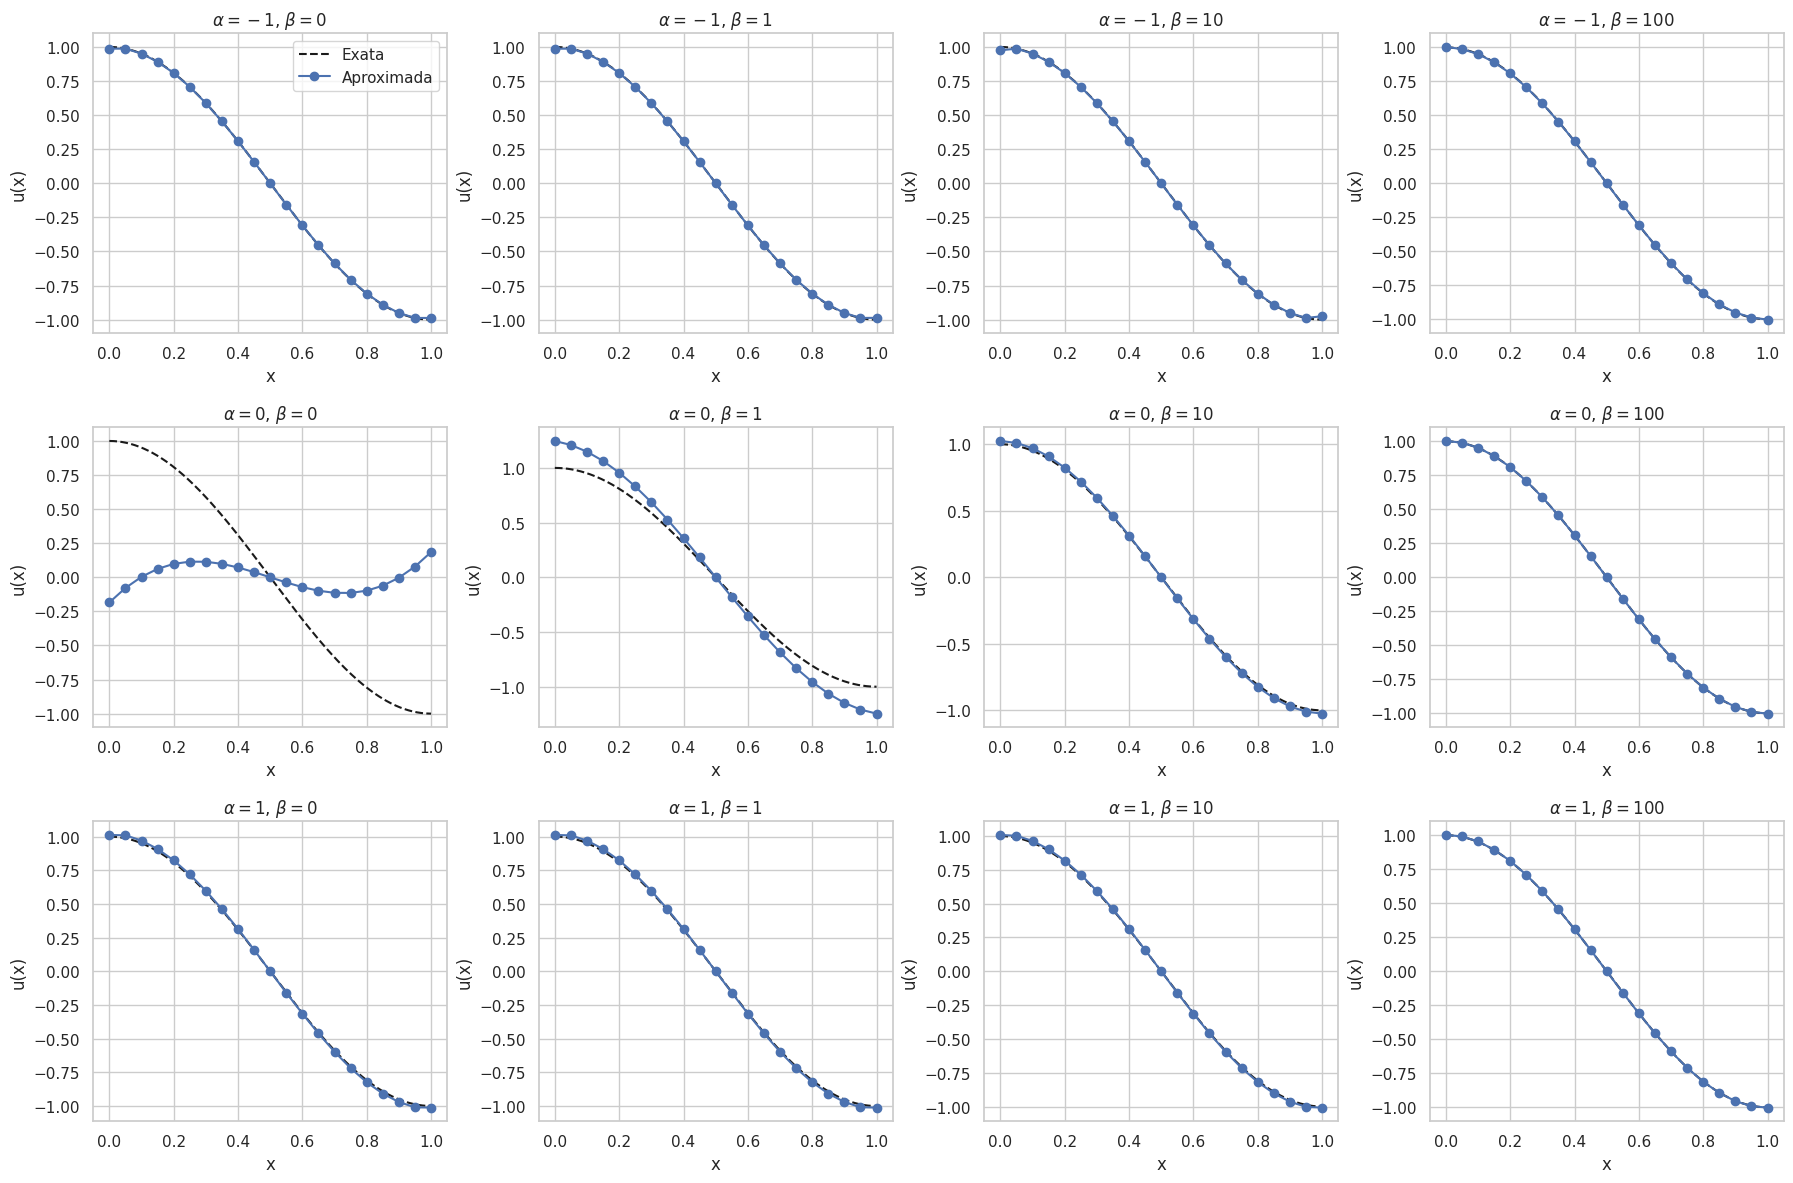

In [15]:
experiment_b()

In [16]:
folder = "./hybridKnownLambdaFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"

directory ./hybridKnownLambdaFEM already created


In [27]:
def local_matrices_discontinuous_known_lambda(x1, x2, alpha, beta):
    # pass
    h = x2 - x1
    J = h / 2.0
    
    # Pontos e pesos da quadratura de Gauss
    gauss_pts, weights = leggauss(2)
    
    K_loc = np.zeros((2, 2))
    F_loc = np.zeros(2)
    
    for gp, w in zip(gauss_pts, weights):
        # Aqui defino as funções de forma (N) e derivadas (dN/dx) para a aproximação linear
        N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])
        dN_dxi = np.array([-0.5, 0.5])
        dN_dx = dN_dxi / J

        # Recupero as coodenadas originais
        x_gp = N[0] * x1 + N[1] * x2
        f_val = exact_f(x_gp)

        for i in range(2):
            for j in range(2):
                K_loc[i, j] += dN_dx[i] * dN_dx[j] * w * J

            F_loc[i] += f_val * N[i] * w * J
    
    # Termos de contorno locais
    
    # Convenção:
    # x1: normal n = -1
    # x2: normal n =  1
    #
    # lambda é conhecido:
    # lambda(x) = u_exata(x)
    
    dN_dx = np.array([-1.0 / h, 1.0 / h])

    boundary_points = [
        # ponto esquerdo do elemento
        {
            "x": x1,
            "normal": -1.0,
            "N": np.array([1.0, 0.0])
        },
        # ponto direito do elemento
        {
            "x": x2,
            "normal": 1.0,
            "N": np.array([0.0, 1.0])
        }
    ]
    
    for bd in boundary_points:
        xb = bd["x"]
        normal = bd["normal"]
        N_boundary = bd["N"]

        lambda_val = exact_u(xb)

        for i in range(2):      # índice da função teste
            # Lado direito:
            # alpha * v' * n * lambda + beta * lambda * v
            F_loc[i] += alpha * dN_dx[i] * normal * lambda_val
            F_loc[i] += beta * lambda_val * N_boundary[i]

            for j in range(2):  # índice da função tentativa
                # Matriz local:
                # - u' * n * v
                K_loc[i, j] += -dN_dx[j] * normal * N_boundary[i]

                # + alpha * v' * n * u
                K_loc[i, j] += alpha * dN_dx[i] * normal * N_boundary[j]

                # + beta * u * v
                K_loc[i, j] += beta * N_boundary[j] * N_boundary[i]

    return K_loc, F_loc    

In [32]:
def solve_discontinuous_known_lambda(l, n_elem, alpha, beta):
    # pass
    nodes, elements = create_mesh(l, n_elem)

    # Como a solução é descontínua, cada elemento tem seus próprios
    # dois graus de liberdade locais.
    u_app = np.zeros((n_elem, 2))
    
    cond_numbers = []

    for elem_id, e in enumerate(elements):
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]

        K_loc, F_loc = local_matrices_discontinuous_known_lambda(
            x1,
            x2,
            alpha,
            beta
        )

        cond_numbers.append(np.linalg.cond(K_loc))

        try:
            u_loc = np.linalg.solve(K_loc, F_loc)
        except np.linalg.LinAlgError:
            print(
                f"Matriz local singular no elemento {elem_id}, "
                f"alpha={alpha}, beta={beta}. Usando mínimos quadrados."
            )
            u_loc = np.linalg.lstsq(K_loc, F_loc, rcond=None)[0]

        u_app[elem_id, :] = u_loc

    return nodes, elements, u_app, cond_numbers


In [38]:
def build_discontinuous_plot_data(nodes, elements, u_app):
    # pass
    x_plot = []
    u_plot = []

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x_plot.append(nodes[n1])
        x_plot.append(nodes[n2])
        x_plot.append(np.nan)

        u_plot.append(u_app[elem_id, 0])
        u_plot.append(u_app[elem_id, 1])
        u_plot.append(np.nan)

    return np.array(x_plot), np.array(u_plot)

In [34]:
def compute_max_jump(elements, u_app):
    # pass
    jumps = []

    for elem_id in range(len(elements) - 1):
        u_left = u_app[elem_id, 1]
        u_right = u_app[elem_id + 1, 0]

        jumps.append(abs(u_left - u_right))

    if len(jumps) == 0:
        return 0.0

    return max(jumps)


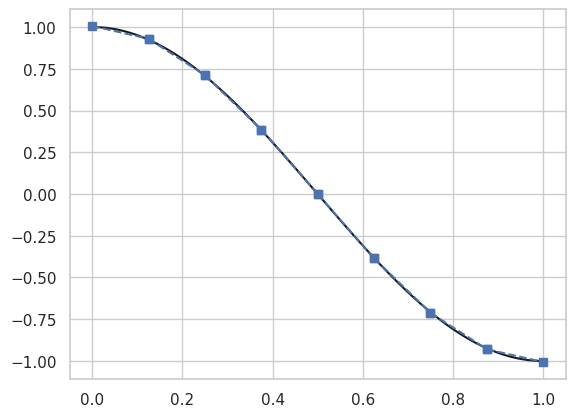

In [59]:
L = 1.0
n_elem = 10

alphas = [-1, 0, 1]
betas = [0, 1, 10, 100]

x_exact = np.linspace(0, L, 300)

nodes, elements, u_app, cond_numbers = solve_discontinuous_known_lambda(L, n_elem=8, alpha=-1, beta=100)

x_disc, u_disc = build_discontinuous_plot_data(nodes, elements, u_app)

plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
plt.plot(x_disc, u_disc, 'bs--', label=r'Descontínua $u_h(x)$')

# plt.legend()

In [40]:
def experiment_d():
    # pass
    L = 1.0
    n_elem = 10

    alphas = [-1, 0, 1]
    betas = [0, 1, 10, 100]

    x_exact = np.linspace(0, L, 300)

    plt.figure(figsize=(18, 12))

    print("RESULTADOS LETRA (d) - FORMULAÇÃO DESCONTÍNUA COM LAMBDA CONHECIDO")
    print("-" * 105)
    print(
        f"{'alpha':<8} | {'beta':<8} | {'Erro L2':<12} | "
        f"{'Max salto':<12} | {'cond max':<12} | {'u_h(0)':<12} | {'u_h(1)':<12}"
    )
    print("-" * 105)

    count = 1

    for alpha in alphas:
        for beta in betas:
            nodes, elements, u_app, cond_numbers = solve_discontinuous_known_lambda(
                L,
                n_elem,
                alpha,
                beta
            )

            x_disc, u_disc = build_discontinuous_plot_data(nodes, elements, u_app)

            err_L2 = compute_L2_error_discontinuous(nodes, elements, u_app)
            max_jump = compute_max_jump(elements, u_app)
            cond_max = max(cond_numbers)

            print(
                f"{alpha:<8} | {beta:<8} | {err_L2:<12.3e} | "
                f"{max_jump:<12.3e} | {cond_max:<12.3e} | "
                f"{u_app[0, 0]:<12.6f} | {u_app[-1, 1]:<12.6f}"
            )

            plt.subplot(len(alphas), len(betas), count)

            plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
            plt.plot(x_disc, u_disc, 'bs--', label=r'Descontínua $u_h(x)$')

            plt.title(rf'$\alpha={alpha}$, $\beta={beta}$')
            plt.xlabel('x')
            plt.ylabel('u(x)')
            plt.grid(True)

            if count == 1:
                plt.legend()

            count += 1

    print("-" * 105)

    plt.tight_layout()
    plt.savefig(folder + "letra_d_descontinua_lambda_conhecido.pdf")
    plt.show()

RESULTADOS LETRA (d) - FORMULAÇÃO DESCONTÍNUA COM LAMBDA CONHECIDO
---------------------------------------------------------------------------------------------------------
alpha    | beta     | Erro L2      | Max salto    | cond max     | u_h(0)       | u_h(1)      
---------------------------------------------------------------------------------------------------------
Matriz local singular no elemento 0, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 1, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 2, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 3, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 4, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 5, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 6, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 7, alpha=-1, beta=0. Usan

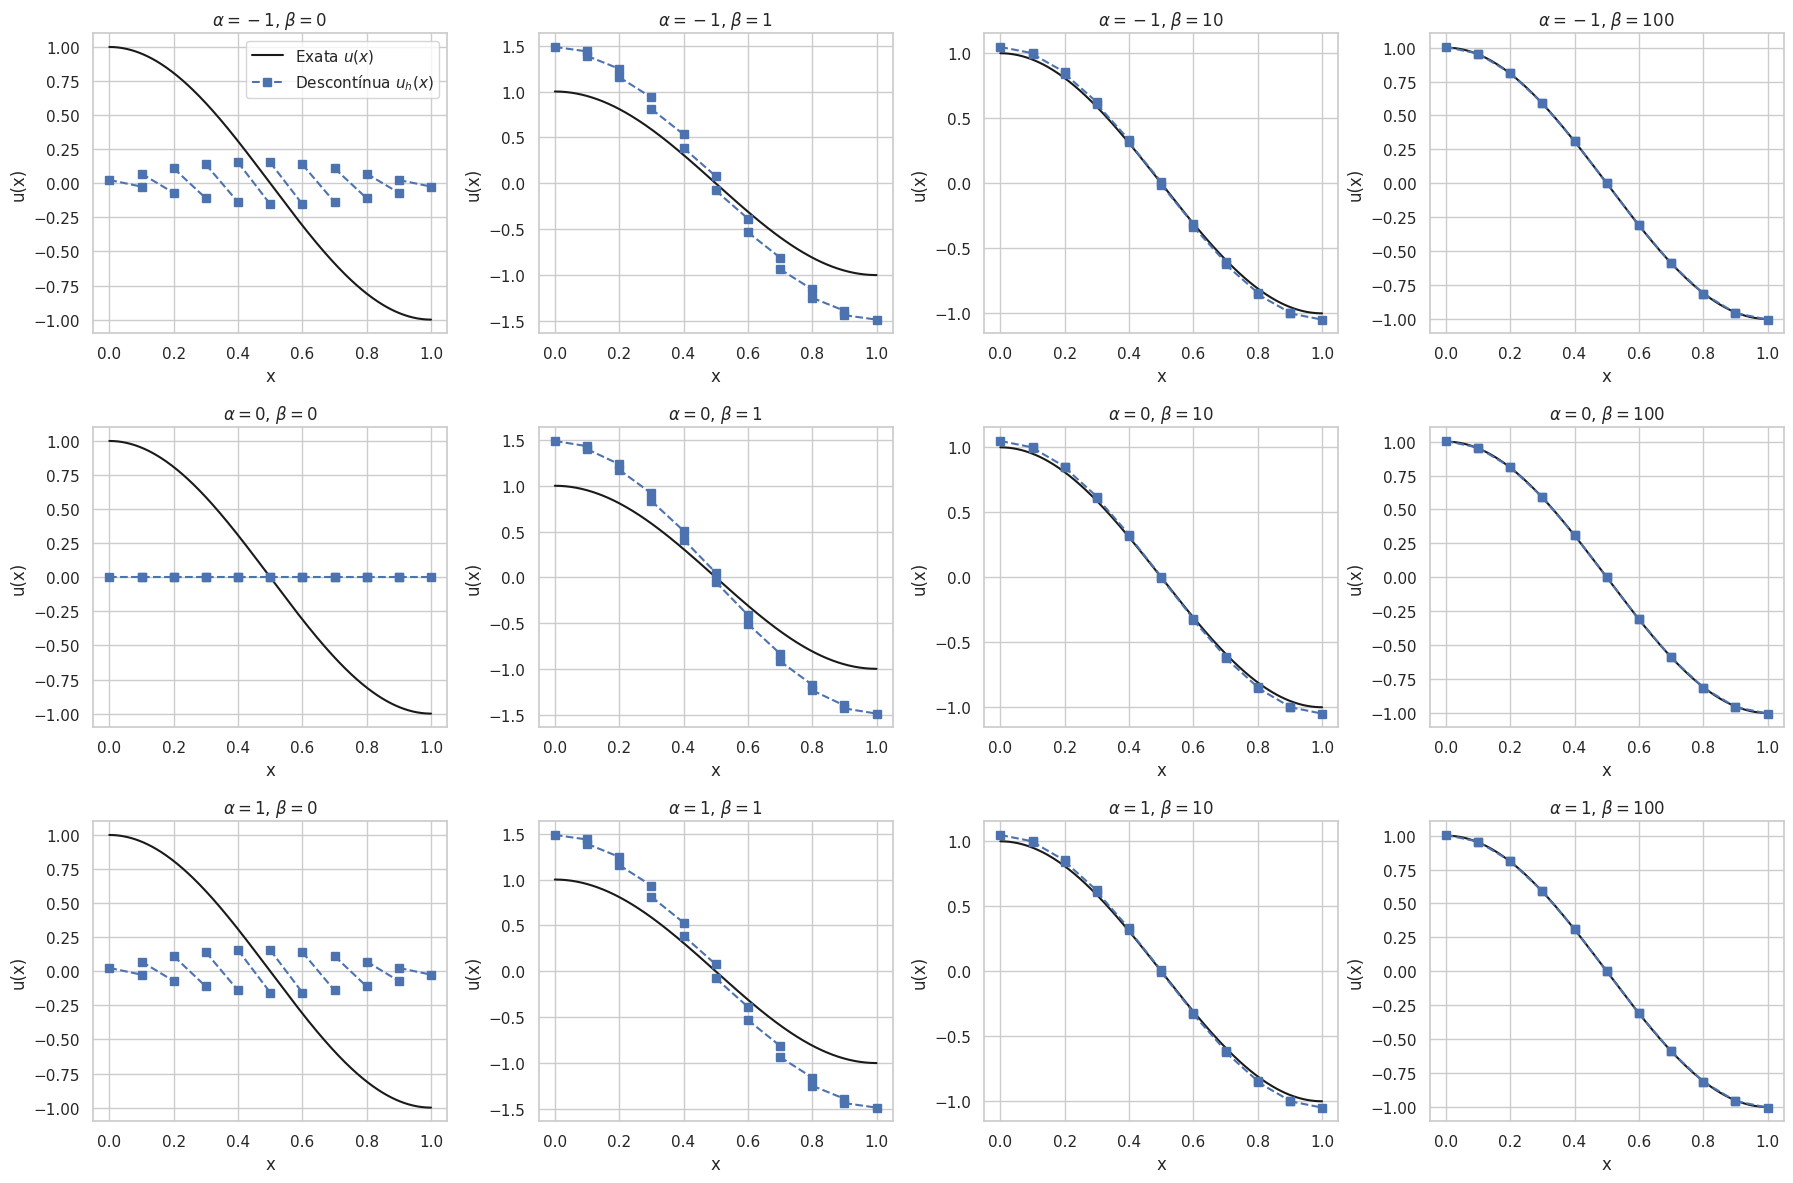

In [41]:
experiment_d()

In [60]:
folder = "./hybridCompleteFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"